In [18]:
!pip install tensorflowjs tensorflow-datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [ ]:
from google.colab import files

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

if not Path("/root/.kaggle/kaggle.json").exists():
    uploaded = files.upload()
    name = next(iter(uploaded))
    shutil.move(name, "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

Saving kaggle.json to kaggle.json


In [ ]:
!rm -rf /content/drive/MyDrive/edit-image-app/data
!mkdir -p /content/drive/MyDrive/edit-image-app/data/div2k /content/drive/MyDrive/edit-image-app/data/art

!kaggle datasets download -d joe1995/div2k-dataset -p /content/drive/MyDrive/edit-image-app/data/div2k --unzip -q
!kaggle datasets download -d thedownhill/art-images-drawings-painting-sculpture-engraving -p /content/drive/MyDrive/edit-image-app/data/art --unzip -q

Dataset URL: https://www.kaggle.com/datasets/joe1995/div2k-dataset
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving
License(s): ODbL-1.0


In [3]:
image_exts = {".jpg", ".jpeg", ".png"}

div2k_root = Path("/content/drive/MyDrive/edit-image-app/data/div2k")
art_root = Path("/content/drive/MyDrive/edit-image-app/data/art")

div2k_paths = [
    str(p) for p in div2k_root.rglob("*")
    if p.suffix.lower() in image_exts and "HR" in str(p)
]

if len(div2k_paths) == 0:
    div2k_paths = [
        str(p) for p in div2k_root.rglob("*")
        if p.suffix.lower() in image_exts
    ]

art_paths = [
    str(p) for p in art_root.rglob("*")
    if p.suffix.lower() in image_exts
]

random.seed(42)
random.shuffle(div2k_paths)
random.shuffle(art_paths)

paths = div2k_paths * 8 + art_paths
random.shuffle(paths)

print("DIV2K:", len(div2k_paths))
print("Art:", len(art_paths))
print("Total with DIV2K repeat:", len(paths))

DIV2K: 900
Art: 12784
Total with DIV2K repeat: 19984


In [4]:
split = int(len(paths) * 0.9)

train_paths = paths[:split]
val_paths = paths[split:]

print("Train:", len(train_paths))
print("Val:", len(val_paths))

Train: 17985
Val: 1999


In [5]:
IMG_SIZE = 96
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

BRIGHTNESS_RANGE = 0.25
CONTRAST_MIN = 0.65
CONTRAST_MAX = 1.45
SATURATION_MIN = 0.65
SATURATION_MAX = 1.45

In [6]:
def load_image(path):
    data = tf.io.read_file(path)

    image = tf.io.decode_jpeg(data, channels=3, try_recover_truncated=True)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], antialias=True)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image


def make_pair(path):
    clean = load_image(path)

    brightness = tf.random.uniform([], -BRIGHTNESS_RANGE, BRIGHTNESS_RANGE)
    contrast = tf.random.uniform([], CONTRAST_MIN, CONTRAST_MAX)
    saturation = tf.random.uniform([], SATURATION_MIN, SATURATION_MAX)

    damaged = tf.image.adjust_brightness(clean, brightness)
    damaged = tf.image.adjust_contrast(damaged, contrast)
    damaged = tf.image.adjust_saturation(damaged, saturation)
    damaged = tf.clip_by_value(damaged, 0.0, 1.0)

    target = tf.stack([
        -brightness,
        1.0 / contrast,
        1.0 / saturation
    ])

    return damaged, target


def make_dataset(file_paths, training=True):
    ds = tf.data.Dataset.from_tensor_slices(file_paths)

    if training:
        ds = ds.shuffle(min(len(file_paths), 3000), reshuffle_each_iteration=True)
        ds = ds.repeat()

    ds = ds.map(make_pair, num_parallel_calls=AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [7]:
train_ds = make_dataset(train_paths, training=True)
val_ds = make_dataset(val_paths, training=False)

x_batch, y_batch = next(iter(train_ds))

print(x_batch.shape)
print(y_batch.shape)
print(tf.reduce_min(x_batch).numpy(), tf.reduce_max(x_batch).numpy())
print(y_batch[:5].numpy())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


(64, 96, 96, 3)
(64, 3)
0.0 1.0
[[ 0.21972102  1.0567963   1.1325535 ]
 [-0.04287308  0.924356    1.0413797 ]
 [-0.06199324  1.2482045   0.99624497]
 [ 0.04450005  0.74005896  1.0602461 ]
 [-0.00896114  1.3925804   1.1797439 ]]


## MODEL

In [8]:
class OutputTransform(tf.keras.layers.Layer):
    def call(self, inputs):
        brightness = 0.35 * tf.tanh(inputs[:, 0:1])
        contrast = 0.55 + 1.10 * tf.sigmoid(inputs[:, 1:2])
        saturation = 0.55 + 1.10 * tf.sigmoid(inputs[:, 2:3])
        return tf.concat([brightness, contrast, saturation], axis=1)

    def get_config(self):
        return super().get_config()

def build_model(size=96):
    inputs = tf.keras.Input(shape=(size, size, 3))

    x = tf.keras.layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(24, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(48, 3, strides=2, padding="same", activation="relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(48, activation="relu")(x)
    raw = tf.keras.layers.Dense(3)(x)

    outputs = OutputTransform()(raw)

    return tf.keras.Model(inputs, outputs)


model = build_model(IMG_SIZE)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 48)       │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           147 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_transform                │ (None, 3)              │             0 │
│ (OutputTransform)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,243 (106.42 KB)

 Trainable params: 27,243 (106.42 KB)

 Non-trainable params: 0 (0.00 B)

## Загрузить модель, чтобы продолжить обучение

In [9]:
import zipfile
import os
from pathlib import Path

keras_path = "/content/drive/MyDrive/edit-image-app/best_model.keras"
extract_dir = "/content/extracted_best_model"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(keras_path, "r") as z:
    z.extractall(extract_dir)

print(os.listdir(extract_dir))

['model.weights.h5', 'config.json', 'metadata.json']


In [10]:
weights_path = "/content/extracted_best_model/model.weights.h5"

model.load_weights(weights_path, skip_mismatch=True)

In [19]:
import json

with open("/content/extracted_best_model/config.json", "r") as f:
    config = json.load(f)

input_shape = config["config"]["layers"][0]["config"]["batch_shape"]
print(input_shape)

[None, 96, 96, 3]


конец

In [11]:
def brightness_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, 0] - y_pred[:, 0]))


def contrast_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, 1] - y_pred[:, 1]))


def saturation_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true[:, 2] - y_pred[:, 2]))

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(delta=0.05),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        brightness_mae,
        contrast_mae,
        saturation_mae
    ]
)

In [ ]:
STEPS_PER_EPOCH = 120
VALIDATION_STEPS = 30
EPOCHS = 25

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/edit-image-app/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)

Epoch 1/25
 96/120 ━━━━━━━━━━━━━━━━━━━━ 2:50 7s/step - brightness_mae: 0.0561 - contrast_mae: 0.1411 - loss: 0.0052 - mae: 0.1268 - saturation_mae: 0.1833

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/edit-image-app/best_model.keras",
    custom_objects={
        "brightness_mae": brightness_mae,
        "contrast_mae": contrast_mae,
        "saturation_mae": saturation_mae
    },
    safe_mode=False
)

## После обучения

In [13]:
def apply_prediction(image, params):
    result = tf.convert_to_tensor(image, dtype=tf.float32)
    result = tf.image.adjust_brightness(result, float(params[0]))
    result = tf.image.adjust_contrast(result, float(params[1]))
    result = tf.image.adjust_saturation(result, float(params[2]))
    result = tf.clip_by_value(result, 0.0, 1.0)
    return result.numpy()

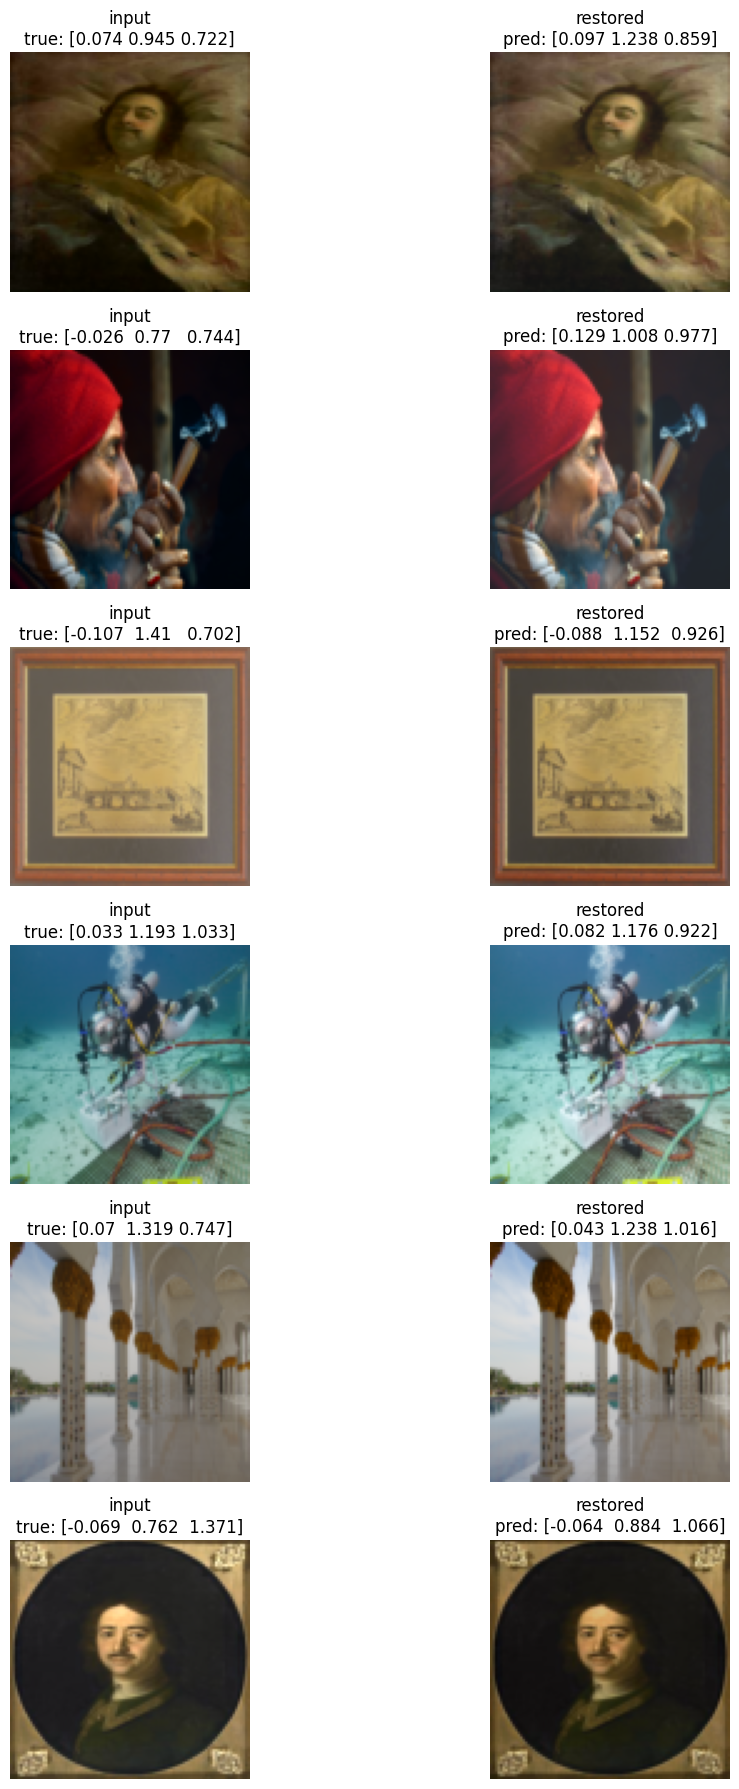

In [14]:
x_val, y_val = next(iter(val_ds))
pred = model.predict(x_val[:6], verbose=0)

plt.figure(figsize=(12, 18))

for i in range(6):
    restored = apply_prediction(x_val[i].numpy(), pred[i])

    plt.subplot(6, 2, i * 2 + 1)
    plt.imshow(x_val[i])
    plt.axis("off")
    plt.title(f"input\ntrue: {y_val[i].numpy().round(3)}")

    plt.subplot(6, 2, i * 2 + 2)
    plt.imshow(restored)
    plt.axis("off")
    plt.title(f"restored\npred: {pred[i].round(3)}")

plt.tight_layout()
plt.show()

In [15]:
model.save("/content/drive/MyDrive/edit-image-app/image_enhancer.keras")
model.export("/content/drive/MyDrive/edit-image-app/saved_model_dir")

Saved artifact at '/content/drive/MyDrive/edit-image-app/saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139471486470096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486469712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486471056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486472784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486472208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486472400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486471248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486471632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486469904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139471486472016: TensorSpec(shape=(), dtype=tf.re

In [20]:
!rm -rf /content/drive/MyDrive/edit-image-app/model_tfjs

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/drive/MyDrive/edit-image-app/saved_model_dir \
    /content/drive/MyDrive/edit-image-app/model_tfjs

shutil.make_archive("/content/drive/MyDrive/edit-image-app/model_tfjs", "zip", "/content/drive/MyDrive/edit-image-app/model_tfjs")
shutil.make_archive("/content/drive/MyDrive/edit-image-app/image_enhancer_keras", "zip", "/content/drive/MyDrive/edit-image-app", "image_enhancer.keras")

2026-05-14 19:54:41.705050: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778788481.742640    7480 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778788481.754435    7480 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778788481.790391    7480 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778788481.790450    7480 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778788481.790460    7480 computation_placer.cc:177] computation placer alr

'/content/drive/MyDrive/edit-image-app/image_enhancer_keras.zip'

In [21]:
from google.colab import files

files.download("/content/drive/MyDrive/edit-image-app/model_tfjs.zip")
files.download("/content/drive/MyDrive/edit-image-app/image_enhancer_keras.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>